SET UP - Import Libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("images", exist_ok=True)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

STEP 1: Data Exploration

In [84]:
# Load Dataset
df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [85]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Missing Values

In [87]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Class Imbalance - to check wheather once dominates the other

In [88]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


STEP 2: Visualization
Pair Plot - to choose top

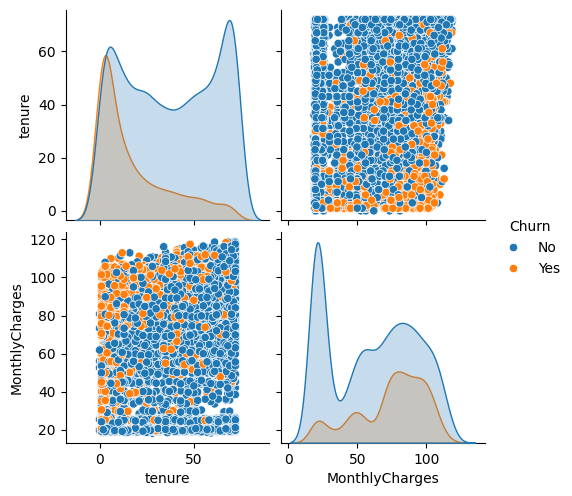

In [89]:
sns.pairplot(df[['tenure',
                 'MonthlyCharges',
                 'TotalCharges',
                 'Churn']],
             hue='Churn')
plt.savefig('images/pairplot.png')
plt.show()

Box Plot

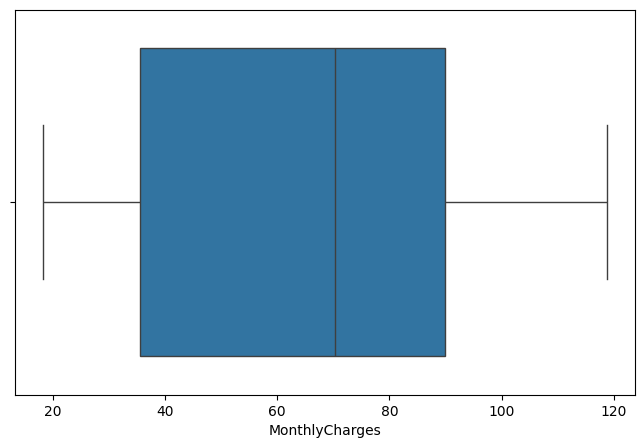

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['MonthlyCharges'])
plt.savefig('images/boxplot.png', dpi=300, bbox_inches="tight")
plt.show()

STEP 3: Data Preprocessing

In [91]:
# Encode Categorical Variables

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [92]:
# Defining X and y

X = df.drop('Churn', axis=1)
y = df['Churn']

Train-Test split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

STEP 4: Train Random Forest

In [94]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Prediction

In [95]:
y_predict = rf.predict(X_test)

Accuracy

In [96]:
accuracy_score = accuracy_score(y_test, y_predict)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.7970191625266146


Hyperparameter Tuning

In [97]:
rf = RandomForestClassifier(n_estimators=200, random_state=42) # Number of trees
rf = RandomForestClassifier(n_estimators=200 ,max_depth=10, random_state=42) # Maximum depth of trees
rf = RandomForestClassifier(n_estimators=300,max_depth=10 ,min_samples_split=5, random_state=42) # Minimum samples split
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       random_state=42)

STEP 5: Evaluation

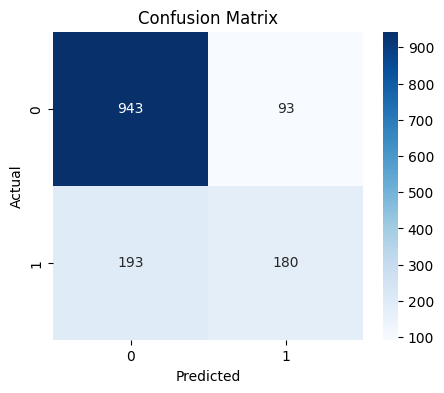

In [98]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_predict)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
# f1 score
f1_score = f1_score(y_test, y_predict)
print(f"F1 Score: {f1_score}")

F1 Score: 0.5572755417956656


In [100]:
# Classification Report
cr = classification_report(y_test, y_predict)
print(f"Classification Report:\n{cr}")

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



Overfitting Check

In [101]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42)
rf.fit(X_train, y_train)

print(f"Training Score: {rf.score(X_train, y_train)}") # Training Score
print(f"Testing Score: {rf.score(X_test, y_test)}") # Testing Score

Training Score: 0.8814341498047569
Testing Score: 0.808374733853797


Feature Importance Plot

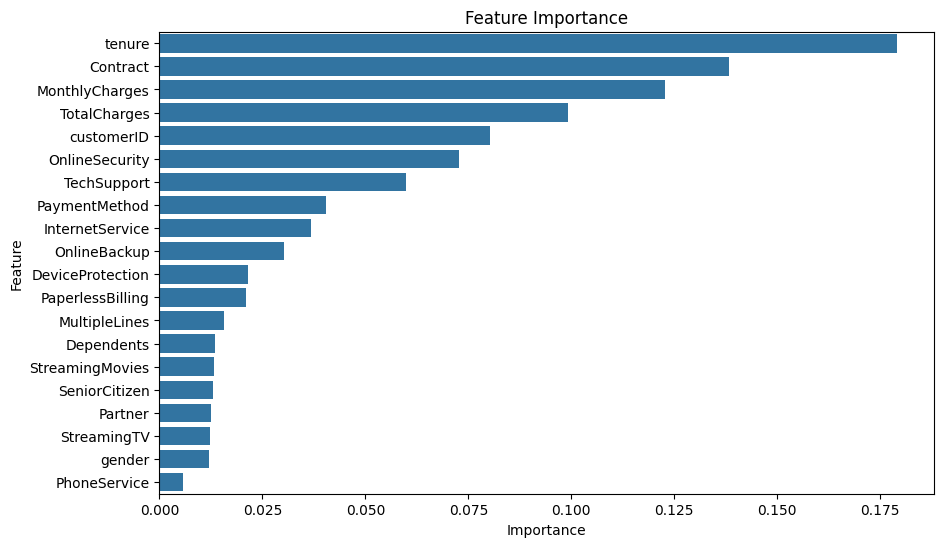

In [102]:
importance = rf.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    'Feature':features,
    'Importance':importance
})

imp_df = imp_df.sort_values(by='Importance',
                            ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=imp_df
)

plt.title("Feature Importance")
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()



In [103]:
print(os.listdir("images"))

['pairplot.png', 'confusion_matrix.png', 'boxplot.png', 'feature_importance.png']


In [104]:
from google.colab import files

files.download("images/pairplot.png")
files.download("images/boxplot.png")
files.download("images/confusion_matrix.png")
files.download("images/feature_importance.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>